In [2]:
from pathlib import Path

DATA_ROOT = Path(r"../DATA")
IMG_EXTS = { ".jpg" }
all_datasets = {}

for split in ["train", "validation", "test"]:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        continue
    print(f"\n{split}/")
    for cls_dir in sorted(split_dir.iterdir()):
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in IMG_EXTS]
        all_datasets[cls_dir.name] = all_datasets.get(cls_dir.name, 0) + len(imgs)
        print(f"  {cls_dir.name:20s}: {len(imgs):>5} images")


train/
  bikini              :   448 images
  bra                 :   444 images
  dress               :   241 images
  longsleeve          :   455 images
  outwear             :   184 images
  pants               :   468 images
  shirt               :   290 images
  shorts              :   202 images
  skirt               :   112 images
  t-shirt             :   795 images
  underwear           :   398 images

validation/
  bikini              :    56 images
  bra                 :    55 images
  dress               :    32 images
  longsleeve          :    49 images
  outwear             :    24 images
  pants               :    49 images
  shirt               :    29 images
  shorts              :    25 images
  skirt               :    12 images
  t-shirt             :    81 images
  underwear           :    48 images

test/
  bikini              :    56 images
  bra                 :    57 images
  dress               :    15 images
  longsleeve          :    72 images
  outwear 

In [3]:
import pandas as pd
dataset_df = pd.DataFrame(pd.Series(all_datasets, name='image_count'))

In [4]:
dataset_df['image_count'].sum()

np.int64(4952)

C:\Users\User\AppData\Local\Temp\ipykernel_28912\1608079946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dataset_df.index, y='image_count', data=dataset_df, palette='summer')


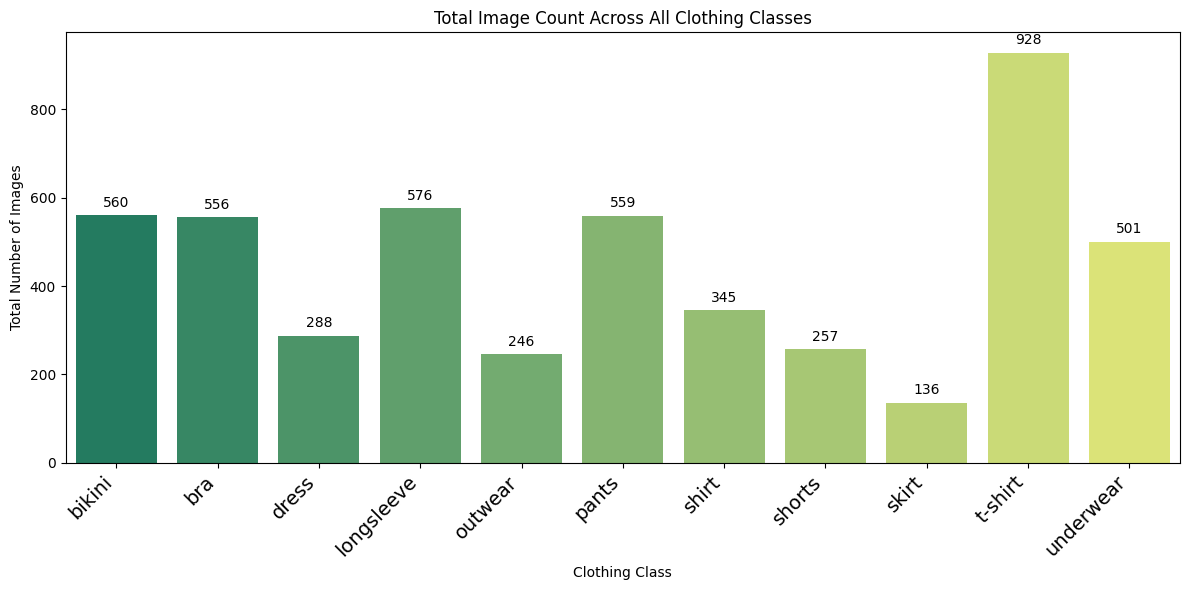

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dataset_df = pd.DataFrame(pd.Series(all_datasets, name='image_count'))

plt.figure(figsize=(12, 6))

ax = sns.barplot(x=dataset_df.index, y='image_count', data=dataset_df, palette='summer')
plt.title('Total Image Count Across All Clothing Classes')
plt.xlabel('Clothing Class')
plt.ylabel('Total Number of Images')
plt.xticks(rotation=45, ha='right', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [6]:
from PIL import Image
import numpy as np

# Load an image
img = Image.open(f'{DATA_ROOT}/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')

# Resize to target size
img = img.resize((224, 224))

# Convert to numpy array
x = np.array(img)
print(x.shape)

(224, 224, 3)


### Pre-trained (mobilenetv2)

In [7]:
import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np

# Load pre-trained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval()

# Preprocessing for MobileNetV2
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [8]:
img = Image.open(f'{DATA_ROOT}/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)

# Make prediction
with torch.no_grad():
    output = model(batch_t)

# Get top predictions
_, indices = torch.sort(output, descending=True)

In [9]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O ../imagenet_classes.txt

# Load ImageNet class names
with open("../imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Get top 5 predictions
top5_indices = indices[0, :5].tolist()
top5_classes = [categories[i] for i in top5_indices]

print("Top 5 predictions:")
for i, class_name in enumerate(top5_classes):
    print(f"{i+1}: {class_name}")

Top 5 predictions:
1: jean
2: suit
3: cardigan
4: sweatshirt
5: overskirt


--2026-03-29 16:08:47--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: '../imagenet_classes.txt'

     0K ..........                                            100% 9.90M=0.001s

2026-03-29 16:08:48 (9.90 MB/s) - '../imagenet_classes.txt' saved [10472/10472]



## Transfer learning

In [10]:
import os
from torch.utils.data import Dataset
from PIL import Image

class ClothingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_path = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = { cls: i for i, cls in enumerate(self.classes) }

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_path.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_path)

    def __getitem__(self, index):
        img_path = self.image_path[index]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
from torchvision import transforms

input_size = 224

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [12]:
from torch.utils.data import DataLoader

train_path = f'{DATA_ROOT}/train'
val_path = f'{DATA_ROOT}/validation'

train_dataset = ClothingDataset(
    data_dir=train_path,
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir=val_path,
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [13]:
import torch.nn as nn
import torchvision.models as models

class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

In [14]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = ClothingClassifierMobileNet(num_classes=11)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

Using device: cuda


In [15]:
import pandas as pd

def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, config=None):
    
    history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

        # Save history
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            **(config if config else {})
        })

    return history

In [16]:
def train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, config=None):
    history = []
    
    ckps_root = '../checkpoints'
    os.makedirs(ckps_root, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels  = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            **(config if config else {})
        })
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint_path = f'{ckps_root}/mobilenet_v2_{epoch + 1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'#! Checkpoint saved: {checkpoint_path}')
            
    return history

In [14]:
def make_model(lr=0.01):
    model = ClothingClassifierMobileNet()
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [23]:
all_history = []

learning_rates = [0.0001, 0.001, 0.01, 0.1]
num_epochs = 100

for lr in learning_rates:
    print(f"\n=== Learning Rate: {lr} ===")
    model, optimizer = make_model(lr=lr)

    history = train_and_evaluate(
        model, optimizer,
        train_loader, val_loader,
        criterion, num_epochs, device,
        config={"lr": lr}
    )

    all_history.extend(history)


=== Learning Rate: 0.0001 ===
Epoch 1/100 | Train Loss: 2.1161, Acc: 0.2933 | Val Loss: 1.8583, Acc: 0.4413
Epoch 2/100 | Train Loss: 1.7140, Acc: 0.5098 | Val Loss: 1.5326, Acc: 0.5391
Epoch 3/100 | Train Loss: 1.4804, Acc: 0.5851 | Val Loss: 1.3392, Acc: 0.6304
Epoch 4/100 | Train Loss: 1.3207, Acc: 0.6468 | Val Loss: 1.1856, Acc: 0.6870
Epoch 5/100 | Train Loss: 1.1961, Acc: 0.6678 | Val Loss: 1.0830, Acc: 0.6913
Epoch 6/100 | Train Loss: 1.1084, Acc: 0.7052 | Val Loss: 1.0019, Acc: 0.7196
Epoch 7/100 | Train Loss: 1.0379, Acc: 0.7164 | Val Loss: 0.9392, Acc: 0.7478
Epoch 8/100 | Train Loss: 0.9928, Acc: 0.7295 | Val Loss: 0.9059, Acc: 0.7348
Epoch 9/100 | Train Loss: 0.9415, Acc: 0.7392 | Val Loss: 0.8657, Acc: 0.7652
Epoch 10/100 | Train Loss: 0.9051, Acc: 0.7441 | Val Loss: 0.8336, Acc: 0.7565
Epoch 11/100 | Train Loss: 0.8689, Acc: 0.7617 | Val Loss: 0.7935, Acc: 0.7783
Epoch 12/100 | Train Loss: 0.8348, Acc: 0.7667 | Val Loss: 0.7785, Acc: 0.7826
Epoch 13/100 | Train Loss: 0.8

In [ ]:
# Save to CSV
df = pd.DataFrame(all_history)
df.to_csv("experiment_lr.csv", index=False)

In [1]:
import pandas as pd 
df = pd.read_csv("experiment_lr.csv")

In [31]:
df = df[(df["lr"] == 0.001) | (df["lr"] == 0.0001) ]

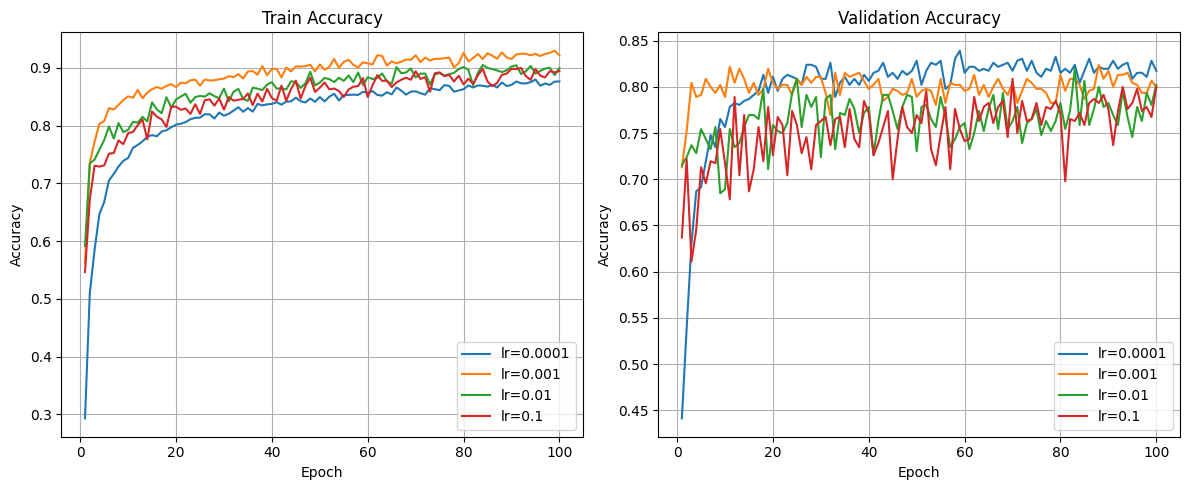

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for lr in df["lr"].unique():
    subset = df[df["lr"] == lr]
    axes[0].plot(subset["epoch"], subset["train_acc"], label=f"lr={lr}")
    axes[1].plot(subset["epoch"], subset["val_acc"], label=f"lr={lr}")

# Titles
axes[0].set_title("Train Accuracy")
axes[1].set_title("Validation Accuracy")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

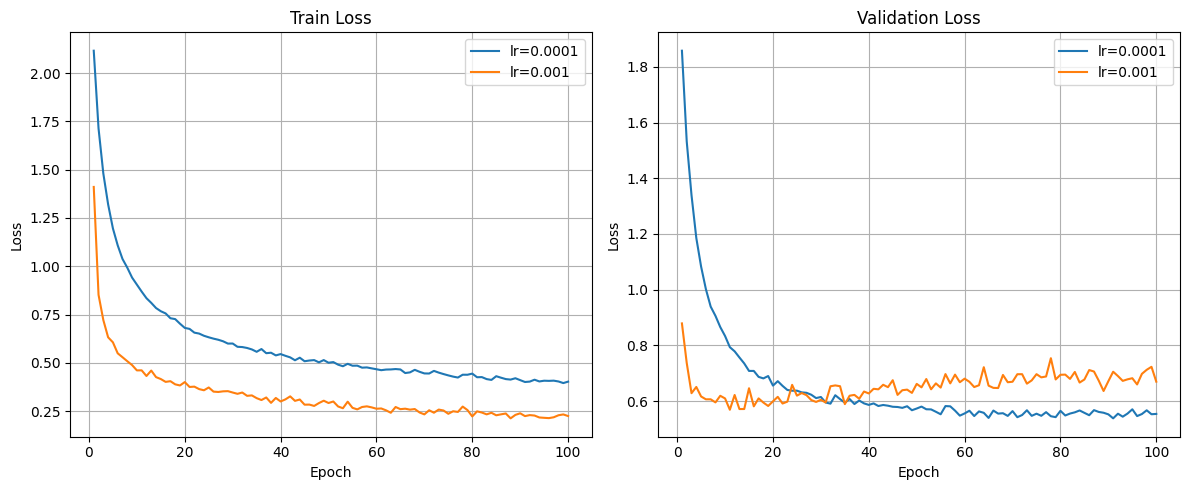

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for lr in df["lr"].unique():
    subset = df[df["lr"] == lr]
    axes[0].plot(subset["epoch"], subset["train_loss"], label=f"lr={lr}")
    axes[1].plot(subset["epoch"], subset["val_loss"], label=f"lr={lr}")

# Titles
axes[0].set_title("Train Loss")
axes[1].set_title("Validation Loss")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Loss")

# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

### Adding Inner Layers

In [14]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [15]:
def make_model(lr=0.0001, size_inner=100):
    model = ClothingClassifierMobileNet(
        num_classes=11,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [20]:
all_history = []

size_inners = [10, 100, 1000]
num_epochs = 100

for size_inner in size_inners:
    print(f"\n=== Size Inner: {size_inner} ===")
    model, optimizer = make_model(lr=0.0001, size_inner=size_inner)
    history = train_and_evaluate(
        model, optimizer,
        train_loader, val_loader,
        criterion, num_epochs, device,
        config={"size_inner": size_inner}
    )
    all_history.extend(history)


=== Size Inner: 10 ===
Epoch 1/100 | Train Loss: 2.3160, Acc: 0.1845 | Val Loss: 2.1641, Acc: 0.2957
Epoch 2/100 | Train Loss: 2.0743, Acc: 0.3205 | Val Loss: 1.9166, Acc: 0.3717
Epoch 3/100 | Train Loss: 1.8772, Acc: 0.3822 | Val Loss: 1.7241, Acc: 0.4826
Epoch 4/100 | Train Loss: 1.7177, Acc: 0.4763 | Val Loss: 1.5741, Acc: 0.5217
Epoch 5/100 | Train Loss: 1.5874, Acc: 0.5375 | Val Loss: 1.4517, Acc: 0.5783
Epoch 6/100 | Train Loss: 1.4800, Acc: 0.5905 | Val Loss: 1.3512, Acc: 0.6130
Epoch 7/100 | Train Loss: 1.3914, Acc: 0.6094 | Val Loss: 1.2727, Acc: 0.6457
Epoch 8/100 | Train Loss: 1.3054, Acc: 0.6366 | Val Loss: 1.1801, Acc: 0.6674
Epoch 9/100 | Train Loss: 1.2309, Acc: 0.6651 | Val Loss: 1.1332, Acc: 0.6978
Epoch 10/100 | Train Loss: 1.1767, Acc: 0.6767 | Val Loss: 1.0844, Acc: 0.6891
Epoch 11/100 | Train Loss: 1.1269, Acc: 0.6866 | Val Loss: 1.0339, Acc: 0.6935
Epoch 12/100 | Train Loss: 1.0890, Acc: 0.6958 | Val Loss: 0.9904, Acc: 0.7022
Epoch 13/100 | Train Loss: 1.0394, Ac

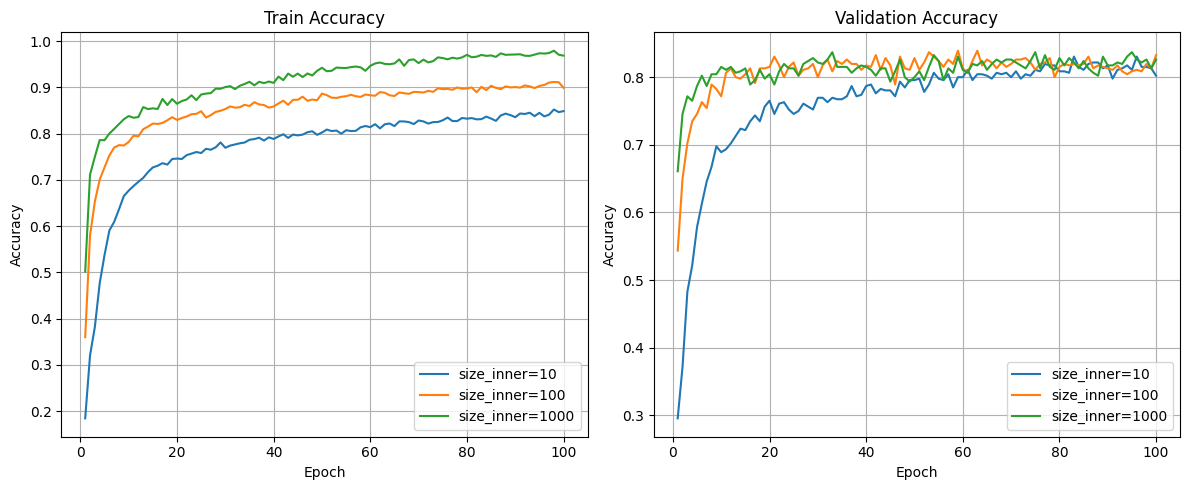

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# df_size_inner = pd.read_csv("experiment_size_inner.csv")
df_size_inner = pd.DataFrame(all_history)
# df_size_inner.to_csv("experiment_size_inner.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for size_inner in df_size_inner["size_inner"].unique():
    subset = df_size_inner[df_size_inner["size_inner"] == size_inner]
    axes[0].plot(subset["epoch"], subset["train_acc"], label=f"size_inner={size_inner}")
    axes[1].plot(subset["epoch"], subset["val_acc"], label=f"size_inner={size_inner}")

# Titles
axes[0].set_title("Train Accuracy")
axes[1].set_title("Validation Accuracy")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

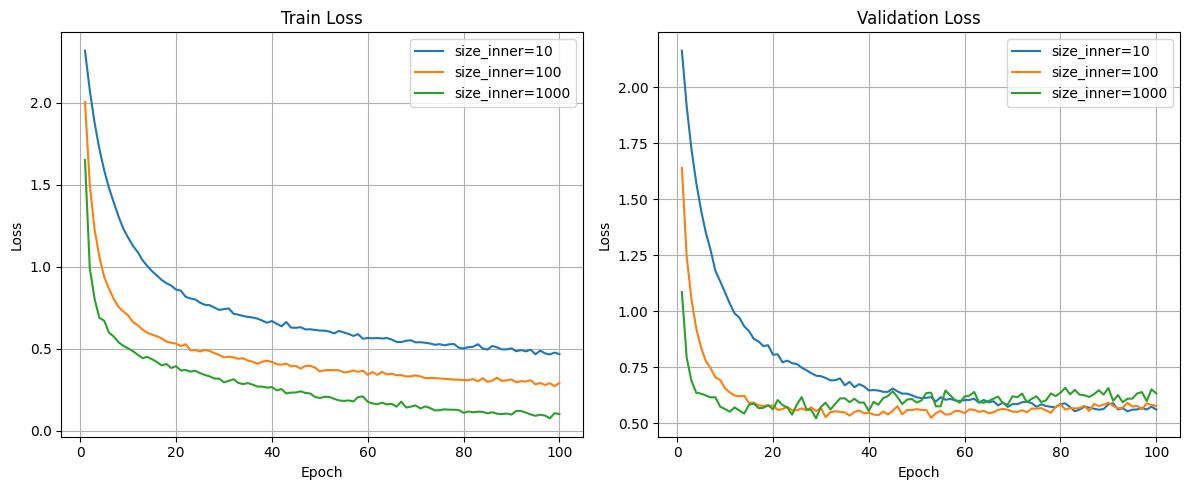

In [25]:
import matplotlib.pyplot as plt
import pandas as pd


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for size_inner in df_size_inner["size_inner"].unique():
    subset = df_size_inner[df_size_inner["size_inner"] == size_inner]
    axes[0].plot(subset["epoch"], subset["train_loss"], label=f"size_inner={size_inner}")
    axes[1].plot(subset["epoch"], subset["val_loss"], label=f"size_inner={size_inner}")

# Titles
axes[0].set_title("Train Loss")
axes[1].set_title("Validation Loss")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Loss")

# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

### Dropout Regularization

In [17]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)
        return x

In [18]:
def make_model(lr=.001, size_inner=100, droprate=0.2):
    model = ClothingClassifierMobileNet(
        num_classes=11,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [28]:
all_history = []

droprates = [0.0, 0.2, 0.5, 0.8]
num_epochs = 100

for droprate in droprates:
    print(f"\n=== droprate: {droprate} ===")
    model, optimizer = make_model(lr=0.0001, size_inner=100, droprate=droprate)
    history = train_and_evaluate(
        model, optimizer,
        train_loader, val_loader,
        criterion, num_epochs, device,
        config={"droprate": droprate}
    )
    all_history.extend(history)


=== droprate: 0.0 ===
Epoch 1/100 | Train Loss: 2.0128, Acc: 0.3550 | Val Loss: 1.6665, Acc: 0.4587
Epoch 2/100 | Train Loss: 1.5175, Acc: 0.5420 | Val Loss: 1.2829, Acc: 0.6022
Epoch 3/100 | Train Loss: 1.2397, Acc: 0.6401 | Val Loss: 1.0795, Acc: 0.6848
Epoch 4/100 | Train Loss: 1.0766, Acc: 0.6963 | Val Loss: 0.9531, Acc: 0.7087
Epoch 5/100 | Train Loss: 0.9481, Acc: 0.7322 | Val Loss: 0.8552, Acc: 0.7283
Epoch 6/100 | Train Loss: 0.8684, Acc: 0.7530 | Val Loss: 0.7801, Acc: 0.7413
Epoch 7/100 | Train Loss: 0.8167, Acc: 0.7615 | Val Loss: 0.7495, Acc: 0.7848
Epoch 8/100 | Train Loss: 0.7598, Acc: 0.7763 | Val Loss: 0.7082, Acc: 0.7696
Epoch 9/100 | Train Loss: 0.7093, Acc: 0.7880 | Val Loss: 0.6621, Acc: 0.7935
Epoch 10/100 | Train Loss: 0.6862, Acc: 0.7976 | Val Loss: 0.6560, Acc: 0.7891
Epoch 11/100 | Train Loss: 0.6473, Acc: 0.8046 | Val Loss: 0.6459, Acc: 0.7978
Epoch 12/100 | Train Loss: 0.6355, Acc: 0.8013 | Val Loss: 0.6221, Acc: 0.7978
Epoch 13/100 | Train Loss: 0.6253, Acc

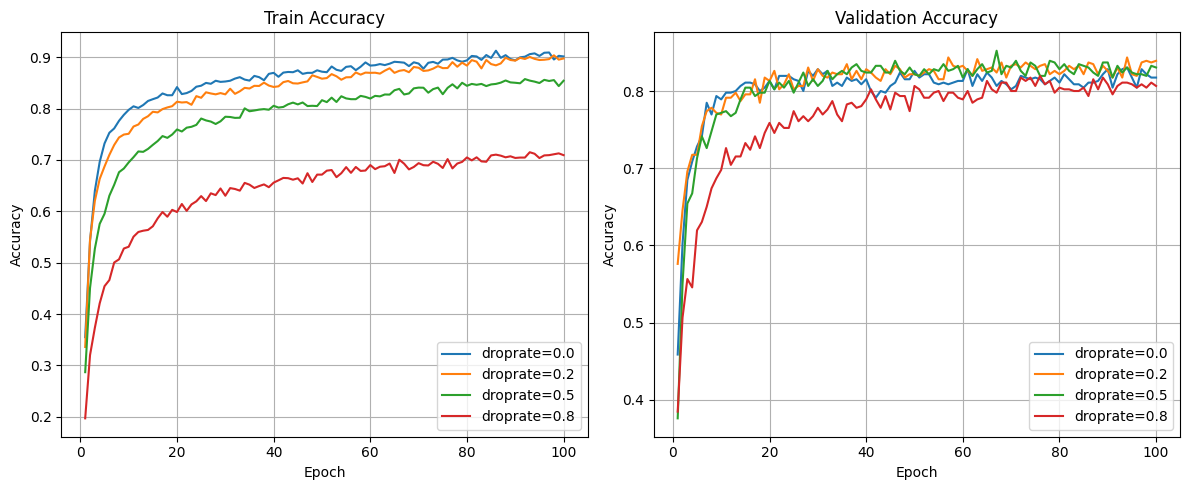

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# df_droprate = pd.read_csv("experiment_droprate.csv")
df_droprate = pd.DataFrame(all_history)
df_droprate.to_csv("experiment_droprate.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for droprate in df_droprate["droprate"].unique():
    subset = df_droprate[df_droprate["droprate"] == droprate]
    axes[0].plot(subset["epoch"], subset["train_acc"], label=f"droprate={droprate}")
    axes[1].plot(subset["epoch"], subset["val_acc"], label=f"droprate={droprate}")

# Titles
axes[0].set_title("Train Accuracy")
axes[1].set_title("Validation Accuracy")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

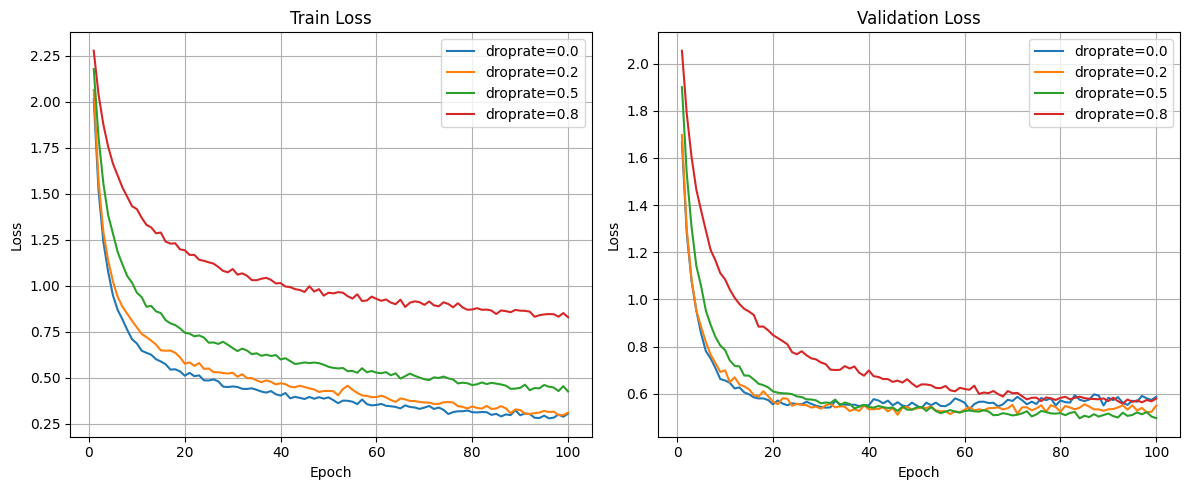

In [30]:
import matplotlib.pyplot as plt
import pandas as pd


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for droprate in df_droprate["droprate"].unique():
    subset = df_droprate[df_droprate["droprate"] == droprate]
    axes[0].plot(subset["epoch"], subset["train_loss"], label=f"droprate={droprate}")
    axes[1].plot(subset["epoch"], subset["val_loss"], label=f"droprate={droprate}")

# Titles
axes[0].set_title("Train Loss")
axes[1].set_title("Validation Loss")

# Labels
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Loss")

# Style
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

### Train with checkpointing

In [30]:
num_epochs = 100
model, optimizer = make_model(lr=0.0001, size_inner=100, droprate=0.2)
history = train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, config={"lr": 0.0001, "size_inner": 100, "droprate": 0.2})

Epoch 1/100 | Train Loss: 2.0684, Acc: 0.3354 | Val Loss: 1.7186, Acc: 0.5239
#! Checkpoint saved: ../checkpoints/mobilenet_v2_01_0.524.pth
Epoch 2/100 | Train Loss: 1.6098, Acc: 0.5328 | Val Loss: 1.3509, Acc: 0.5739
#! Checkpoint saved: ../checkpoints/mobilenet_v2_02_0.574.pth
Epoch 3/100 | Train Loss: 1.3460, Acc: 0.5995 | Val Loss: 1.1273, Acc: 0.6543
#! Checkpoint saved: ../checkpoints/mobilenet_v2_03_0.654.pth
Epoch 4/100 | Train Loss: 1.1660, Acc: 0.6604 | Val Loss: 0.9931, Acc: 0.7043
#! Checkpoint saved: ../checkpoints/mobilenet_v2_04_0.704.pth
Epoch 5/100 | Train Loss: 1.0512, Acc: 0.6805 | Val Loss: 0.9057, Acc: 0.7413
#! Checkpoint saved: ../checkpoints/mobilenet_v2_05_0.741.pth
Epoch 6/100 | Train Loss: 0.9761, Acc: 0.6963 | Val Loss: 0.8188, Acc: 0.7522
#! Checkpoint saved: ../checkpoints/mobilenet_v2_06_0.752.pth
Epoch 7/100 | Train Loss: 0.9218, Acc: 0.7231 | Val Loss: 0.7967, Acc: 0.7565
#! Checkpoint saved: ../checkpoints/mobilenet_v2_07_0.757.pth
Epoch 8/100 | Train 

In [31]:
df_trained_history = pd.DataFrame(history)
df_trained_history.to_csv("trained_history.csv", index=False)

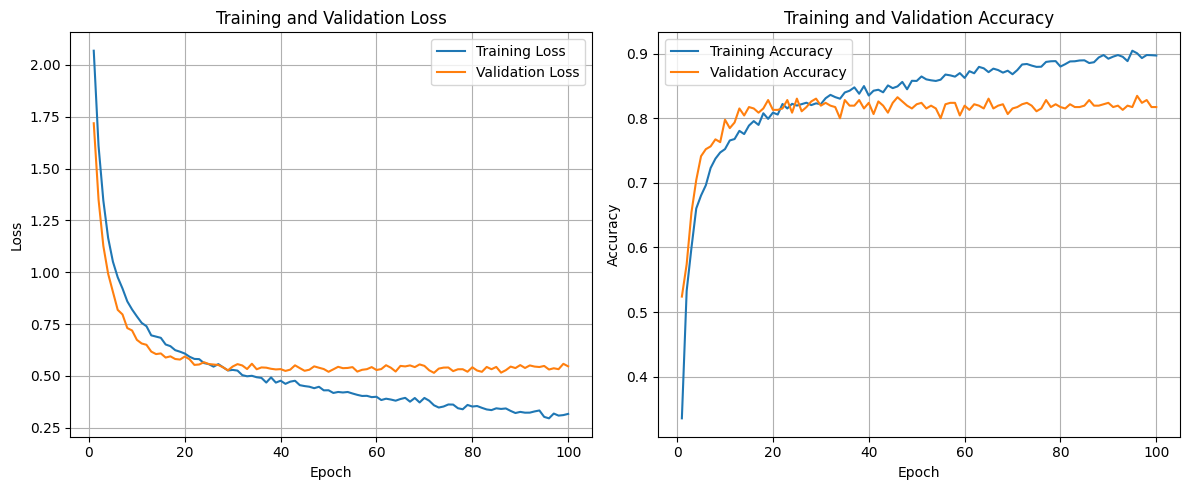

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_trained_history['epoch'], df_trained_history['train_loss'], label='Training Loss')
plt.plot(df_trained_history['epoch'], df_trained_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df_trained_history['epoch'], df_trained_history['train_acc'], label='Training Accuracy')
plt.plot(df_trained_history['epoch'], df_trained_history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix on Test Set

In [19]:
def evaluate_on_loader(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = running_loss / len(data_loader)
    acc = correct / total
    return avg_loss, acc, all_preds, all_labels

In [21]:
from torch.utils.data import DataLoader
from torchvision import transforms

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
test_path    = f"{DATA_ROOT}/test"
test_dataset = ClothingDataset(data_dir=test_path, transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

test_loss, test_acc, all_preds, all_labels = evaluate_on_loader(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss: 0.4771 | Test Accuracy: 0.8440 (84.40%)


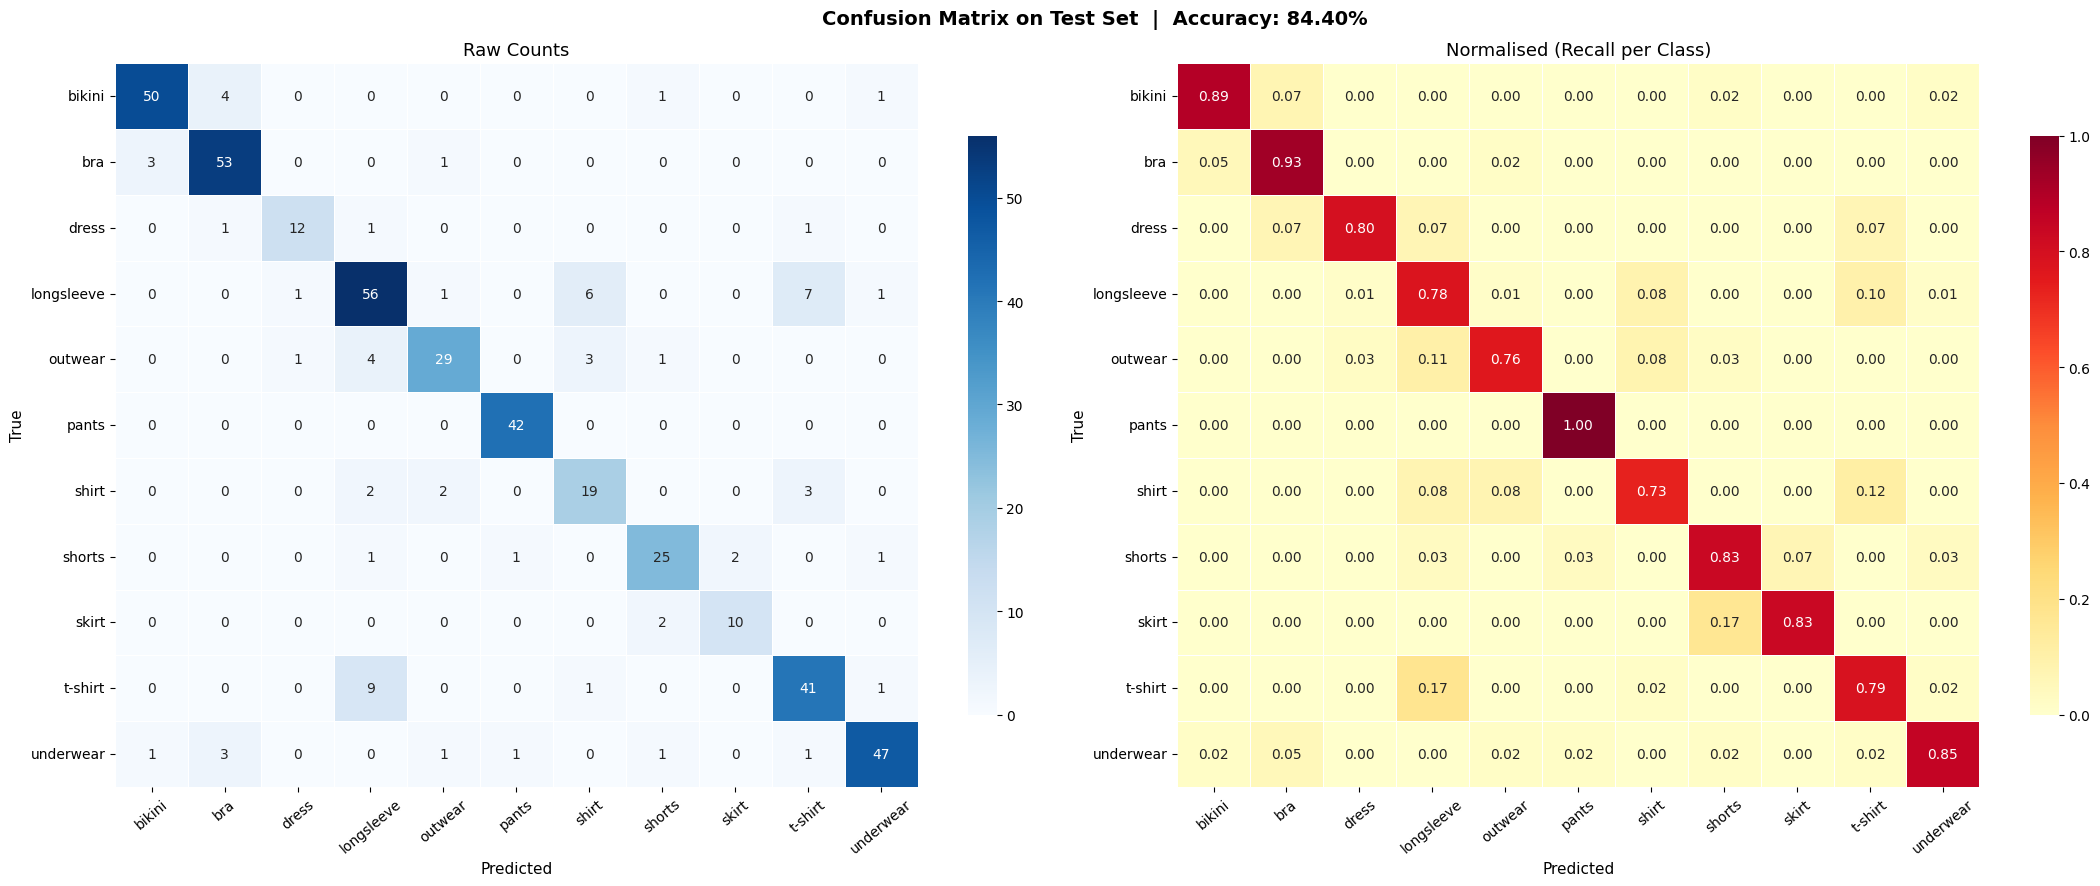

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

classes = [
    "bikini", "bra", "dress", "longsleeve", "outwear", "pants",
    "shirt", "shorts", "skirt", "t-shirt", "underwear"
]

cm   = confusion_matrix(all_labels, all_preds)
cm_n = cm.astype("float") / cm.sum(axis=1, keepdims=True)   

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(f"Confusion Matrix on Test Set  |  Accuracy: {test_acc*100:.2f}%",
             fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Raw Counts", fontsize=13)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True", fontsize=11)
axes[0].tick_params(axis="x", rotation=40)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1,
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Normalised (Recall per Class)", fontsize=13)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True", fontsize=11)
axes[1].tick_params(axis="x", rotation=40)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [27]:
confusion_matrix(all_labels, all_preds)

array([[50,  4,  0,  0,  0,  0,  0,  1,  0,  0,  1],
       [ 3, 53,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  1, 12,  1,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  1, 56,  1,  0,  6,  0,  0,  7,  1],
       [ 0,  0,  1,  4, 29,  0,  3,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 42,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  2,  0, 19,  0,  0,  3,  0],
       [ 0,  0,  0,  1,  0,  1,  0, 25,  2,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  2, 10,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  1,  0,  0, 41,  1],
       [ 1,  3,  0,  0,  1,  1,  0,  1,  0,  1, 47]])

In [25]:
print(classification_report(all_labels, all_preds, target_names=classes, digits=4)) 

              precision    recall  f1-score   support

      bikini     0.9259    0.8929    0.9091        56
         bra     0.8689    0.9298    0.8983        57
       dress     0.8571    0.8000    0.8276        15
  longsleeve     0.7671    0.7778    0.7724        72
     outwear     0.8529    0.7632    0.8056        38
       pants     0.9545    1.0000    0.9767        42
       shirt     0.6552    0.7308    0.6909        26
      shorts     0.8333    0.8333    0.8333        30
       skirt     0.8333    0.8333    0.8333        12
     t-shirt     0.7736    0.7885    0.7810        52
   underwear     0.9216    0.8545    0.8868        55

    accuracy                         0.8440       455
   macro avg     0.8403    0.8367    0.8377       455
weighted avg     0.8460    0.8440    0.8442       455



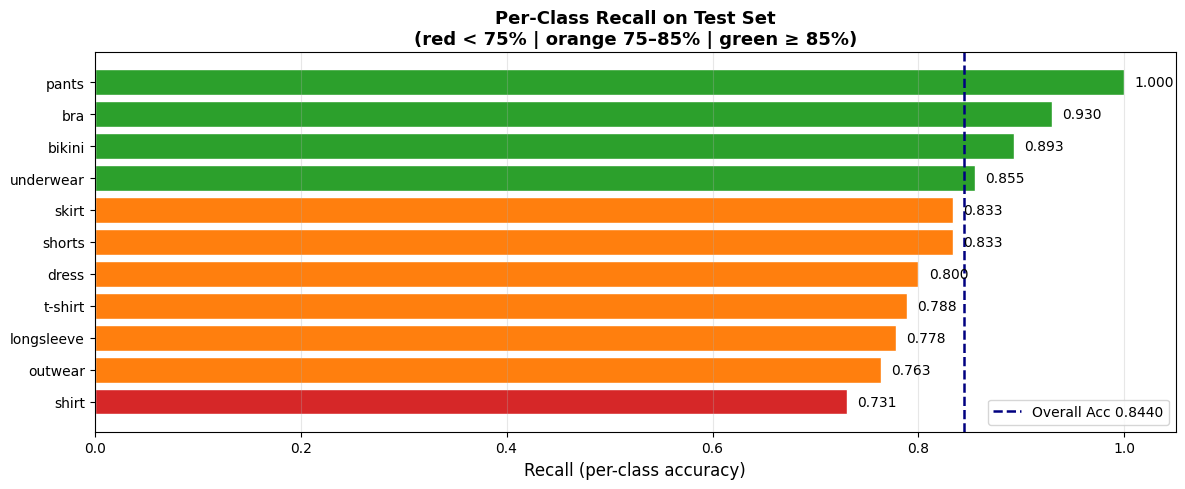

In [26]:
per_class_acc = cm_n.diagonal()
sorted_idx    = np.argsort(per_class_acc)
sorted_cls    = [classes[i] for i in sorted_idx]
sorted_acc    = per_class_acc[sorted_idx]
bar_colors    = ["#d62728" if a < 0.75 else "#2ca02c" if a >= 0.85 else "#ff7f0e"
                 for a in sorted_acc]

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(sorted_cls, sorted_acc, color=bar_colors, edgecolor="white")
ax.set_xlim(0, 1.05)
ax.axvline(x=test_acc, color="navy", linewidth=1.8, linestyle="--",
           label=f"Overall Acc {test_acc:.4f}")
for bar, val in zip(bars, sorted_acc):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)
ax.set_xlabel("Recall (per-class accuracy)", fontsize=12)
ax.set_title("Per-Class Recall on Test Set\n(red < 75% | orange 75–85% | green ≥ 85%)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

### Using the Trained Model

In [19]:
import glob
import os

list_of_files = glob.glob('../checkpoints/mobilenet_v2_*.pth')
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Loading model from: {latest_file}")

# Load model
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.2, num_classes=11)
model.load_state_dict(torch.load(latest_file))
model.to(device)
model.eval()

Loading model from: ../checkpoints\mobilenet_v2_96_0.835.pth


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [20]:
from keras_image_helper import create_preprocessor
import numpy as np

def preprocess_pytorch_style(X):
    X = X / 255.0

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)

    X = X.transpose(0, 3, 1, 2)

    X = (X - mean) / std
    return X.astype(np.float32)

In [21]:
preprocessor = create_preprocessor(preprocess_pytorch_style, target_size=(224, 224))

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT3DUy2YtGR8AN35l0PsepNr4_E3tNT8YOzjA&s"
X = preprocessor.from_url(url)
X = torch.Tensor(X).to(device)

with torch.no_grad():
    pred = model(X).cpu().numpy()[0]

classes = [
    "bikini", "bra", "dress", "longsleeve", "outwear", "pants",
    "shirt", "shorts", "skirt", "t-shirt", "underwear"
]

result = dict(zip(classes, pred.tolist()))
result

{'bikini': -0.3628111183643341,
 'bra': -4.6575236320495605,
 'dress': -5.689056396484375,
 'longsleeve': -6.7383131980896,
 'outwear': -6.760207176208496,
 'pants': -1.3803104162216187,
 'shirt': -9.870196342468262,
 'shorts': 0.13566625118255615,
 'skirt': -1.2771000862121582,
 't-shirt': -4.34750509262085,
 'underwear': 9.798517227172852}

In [22]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import requests
import torch.nn.functional as F

def predict_image_from_url(image_url, model, preprocessor, classes, device):
    # Load the image from URL
    response = requests.get(image_url)
    img_raw = Image.open(io.BytesIO(response.content)).convert('RGB')

    X = preprocessor.from_url(image_url)
    X = torch.Tensor(X).to(device)

    with torch.no_grad():
        logits = model(X)
        probabilities = F.softmax(logits, dim=1).cpu().numpy()[0] # Apply softmax

    results = dict(zip(classes, probabilities.tolist()))

    # Get the top prediction
    top_class = max(results, key=results.get)
    top_percentage = results[top_class] * 100 # Convert to percentage

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img_raw)
    plt.title(f"Prediction: {top_class} ({top_percentage:.2f}%)") # Update title
    plt.axis('off')
    plt.show()

    print(f"All predictions for image from URL: {image_url}")
    for cls_name, prob in sorted(results.items(), key=lambda item: item[1], reverse=True):
        print(f"  {cls_name}: {prob:.2%}") # Print as percentage

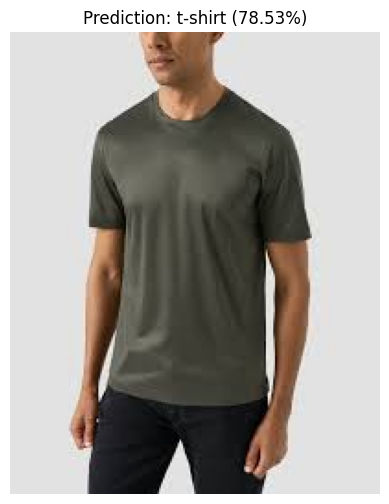

All predictions for image from URL: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwX2vRn4H8lA1ace9kHApugNbtNvlaRczcOw&s
  t-shirt: 78.53%
  dress: 9.42%
  bra: 7.95%
  longsleeve: 2.61%
  underwear: 0.95%
  shirt: 0.43%
  pants: 0.07%
  outwear: 0.01%
  skirt: 0.01%
  shorts: 0.01%
  bikini: 0.00%


In [36]:
test_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwX2vRn4H8lA1ace9kHApugNbtNvlaRczcOw&s"
predict_image_from_url(test_url, model, preprocessor, classes, device)

In [24]:
def predict_image_from_path(image_path, model, classes, device):
    img_raw = Image.open(image_path).convert('RGB')

    # Use the same preprocessing as training/inference above.
    img_resized = img_raw.resize((224, 224))
    X = np.array(img_resized)[None, ...]
    X = preprocess_pytorch_style(X)
    X = torch.Tensor(X).to(device)

    with torch.no_grad():
        logits = model(X)
        probabilities = F.softmax(logits, dim=1).cpu().numpy()[0]

    results = dict(zip(classes, probabilities.tolist()))

    top_class = max(results, key=results.get)
    top_percentage = results[top_class] * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(img_raw)
    plt.title(f"Prediction: {top_class} ({top_percentage:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"All predictions for image from path: {image_path}")
    for cls_name, prob in sorted(results.items(), key=lambda item: item[1], reverse=True):
        print(f"  {cls_name}: {prob:.2%}")

    return results

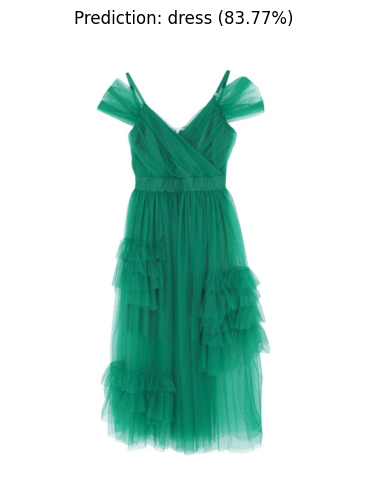

All predictions for image from path: d:\CADT\Year_3-Term_2\Capstone\VITON SIZE SUGGESTS\frontend\public\garments\dress\053744_1.jpg
  dress: 83.77%
  skirt: 5.89%
  underwear: 4.80%
  bra: 4.39%
  bikini: 0.59%
  shirt: 0.17%
  t-shirt: 0.14%
  longsleeve: 0.10%
  shorts: 0.09%
  outwear: 0.05%
  pants: 0.01%


{'bikini': 0.00587064353749156,
 'bra': 0.04391806945204735,
 'dress': 0.8377290964126587,
 'longsleeve': 0.000979872071184218,
 'outwear': 0.0005055675865150988,
 'pants': 7.792803808115423e-05,
 'shirt': 0.0017393704038113356,
 'shorts': 0.0009357729577459395,
 'skirt': 0.05890790373086929,
 't-shirt': 0.001370951533317566,
 'underwear': 0.04796481505036354}

In [30]:
test_path = r"d:\CADT\Year_3-Term_2\Capstone\VITON SIZE SUGGESTS\frontend\public\garments\dress\053744_1.jpg"
predict_image_from_path(test_path, model, classes, device)

### Export to ONNX

In [37]:
import os

dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "../model/clothing_classifier_moblienet_v2.onnx"

# Create the directory if it doesn't exist
onnx_dir = os.path.dirname(onnx_path)
os.makedirs(onnx_dir, exist_ok=True)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Model exported to {onnx_path}")

C:\Users\User\AppData\Local\Temp\ipykernel_24432\2210431175.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0325 19:58:04.238000 24432 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0325 19:58:04.238000 24432 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0325 19:58:04.244000 24432 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for paramete

[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 105 of general pattern rewrite rules.
Model exported to ../model/clothing_classifier_moblienet_v2.onnx
